In [56]:
import numpy as np
import jax
import jax.numpy as jnp
from exciting_environments import EnvironmentRegistry
from exciting_environments.pmsm import MotorVariant
import matplotlib.pyplot as plt
import equinox as eqx
from exciting_environments.utils import MinMaxNormalization
from scipy.io import loadmat
from pathlib import Path
import optax
from scipy.interpolate import griddata

In [7]:
BATCH_SIZE=1
new_motor_env = EnvironmentRegistry.PMSM.make(
    batch_size=BATCH_SIZE,
    saturated=True,
    motor_variant=MotorVariant.BRUSA,
    control_state=["torque"]
    )

In [64]:
def prepare_lut_for_fitting(pmsm_lut: dict):
    id_vec = np.asarray(pmsm_lut["i_d_vec"]).ravel()
    iq_vec = np.asarray(pmsm_lut["i_q_vec"]).ravel()

    def fill_nans(arr2d):
        arr = arr2d.copy().astype(float)
        xi, yi = np.indices(arr.shape)
        mask = np.isnan(arr)
        if mask.any():
            arr[mask] = griddata(
                (xi[~mask], yi[~mask]),
                arr[~mask],
                (xi[mask], yi[mask]),
                method="nearest",
            )
        return arr

    psi_d_raw = fill_nans(np.asarray(pmsm_lut["Psi_d"]))
    psi_q_raw = fill_nans(np.asarray(pmsm_lut["Psi_q"]))
    L_dd_raw  = fill_nans(np.asarray(pmsm_lut["L_dd"]))
    L_dq_raw  = fill_nans(np.asarray(pmsm_lut["L_dq"]))
    L_qd_raw  = fill_nans(np.asarray(pmsm_lut["L_qd"]))
    L_qq_raw  = fill_nans(np.asarray(pmsm_lut["L_qq"]))

    psi_d_max = float(np.max(np.abs(psi_d_raw)))
    psi_q_max = float(np.max(np.abs(psi_q_raw)))
    i_max     = float(max(np.max(np.abs(id_vec)), np.max(np.abs(iq_vec))))
    L_dd_max  = float(np.max(np.abs(L_dd_raw)))
    L_qq_max  = float(np.max(np.abs(L_qq_raw)))
    L_dq_max  = float(max(np.max(np.abs(L_dq_raw)), np.max(np.abs(L_qd_raw))))

    norm = {
        "psi_d_max": psi_d_max,
        "psi_q_max": psi_q_max,
        "L_dd_max":  L_dd_max,
        "L_qq_max":  L_qq_max,
        "L_dq_max":  L_dq_max,
        "i_max":     i_max,
    }


    id_grid_pu = jnp.array(id_vec / i_max)   # p.u.
    iq_grid_pu = jnp.array(iq_vec / i_max)   # p.u.
    id_grid_A  = jnp.array(id_vec)           # [A]
    iq_grid_A  = jnp.array(iq_vec)           # [A]

    luts_pu = {
        "psi_d": jnp.array(psi_d_raw.T / psi_d_max),   
        "psi_q": jnp.array(psi_q_raw.T / psi_q_max),
        "L_dd":  jnp.array(L_dd_raw.T  / L_dd_max),
        "L_dq":  jnp.array(L_dq_raw.T  / L_dq_max),
        "L_qd":  jnp.array(L_qd_raw.T  / L_dq_max),   
        "L_qq":  jnp.array(L_qq_raw.T  / L_qq_max),
    }

    luts_phys = {
        "psi_d": jnp.array(psi_d_raw.T),   
        "psi_q": jnp.array(psi_q_raw.T),  
        "L_dd":  jnp.array(L_dd_raw.T),   
        "L_dq":  jnp.array(L_dq_raw.T),    
        "L_qd":  jnp.array(L_qd_raw.T),    
        "L_qq":  jnp.array(L_qq_raw.T),    
    }

    return id_grid_pu, iq_grid_pu, id_grid_A, iq_grid_A, luts_pu, luts_phys, norm

In [26]:
notebook_dir = Path.cwd().parent
lut_raw = loadmat(notebook_dir / "exciting_environments/pmsm/LUT_BRUSA_jax_grad.mat")

In [36]:
lut_raw["i_d_vec"]

array([[-250, -240, -230, -220, -210, -200, -190, -180, -170, -160, -150,
        -140, -130, -120, -110, -100,  -90,  -80,  -70,  -60,  -50,  -40,
         -30,  -20,  -10,    0]], dtype=int16)

In [65]:
id_grid_pu, iq_grid_pu, id_grid_A, iq_grid_A, luts_pu, luts_phys, norm = prepare_lut_for_fitting(lut_raw)


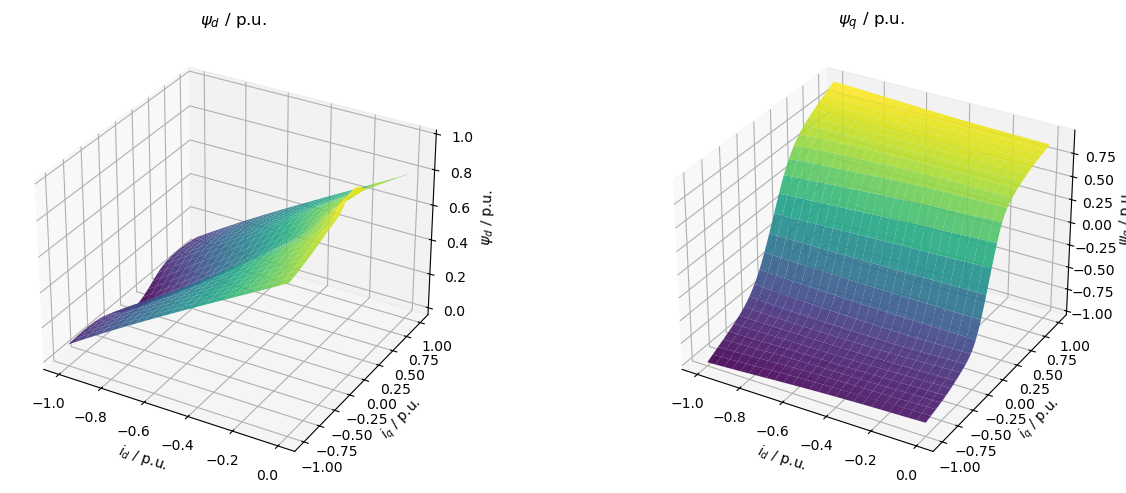

In [66]:
import matplotlib.pyplot as plt
import numpy as np

ID, IQ = jnp.meshgrid(id_grid_pu, iq_grid_pu, indexing='ij')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={'projection': '3d'})

for ax, data, title in zip(axes, [luts_pu["psi_d"],luts_pu["psi_q"]], [r'$\psi_d$ / p.u.', r'$\psi_q$ / p.u.']):
    ax.plot_surface(np.array(ID), np.array(IQ), np.array(data), cmap='viridis', alpha=0.9)
    ax.set_xlabel(r'$i_d$ / p.u.')
    ax.set_ylabel(r'$i_q$ / p.u.')
    ax.set_zlabel(title)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [67]:
class FluxLinkageSaturator2(eqx.Module):
    ad_self1:  jax.Array   # 3
    aq_self:   jax.Array   # 3
    ad_cross1: jax.Array   # n
    aq_cross1: jax.Array   # n  
    k1:        jax.Array   # n 

    ad_self2:  jax.Array   # 3
    ad_cross2: jax.Array   # n
    aq_cross2: jax.Array   # n
    k2:        jax.Array   # n

    id_split:  jax.Array
    psi_d_max: jax.Array   
    psi_q_max: jax.Array
    i_max:     jax.Array
    n: int = eqx.field(static=True)

    def __init__(self, key, norm, n=4, id_split=-0.4):
        self.n = n
        self.id_split  = jnp.array(id_split)
        self.psi_d_max = jnp.array(norm["psi_d_max"])
        self.psi_q_max = jnp.array(norm["psi_q_max"])
        self.i_max     = jnp.array(norm["i_max"])

        keys = jax.random.split(key, num=10)

        self.ad_self1  = jax.random.uniform(keys[0], shape=(3,), minval=0.0, maxval=1.0)
        self.aq_self   = jax.random.uniform(keys[1], shape=(3,), minval=0.0, maxval=1.0)
        self.ad_cross1 = jax.random.uniform(keys[2], shape=(n,), minval=0.0, maxval=1.0)
        self.aq_cross1 = jax.random.uniform(keys[3], shape=(n,), minval=0.0, maxval=1.0)
        self.k1        = jax.random.uniform(keys[4], shape=(n,), minval=0.0, maxval=0.1)

        self.ad_self2  = jax.random.uniform(keys[5], shape=(3,), minval=0.0, maxval=1.0)
        self.ad_cross2 = jax.random.uniform(keys[6], shape=(n,), minval=0.0, maxval=1.0)
        self.aq_cross2 = jax.random.uniform(keys[7], shape=(n,), minval=0.0, maxval=1.0)
        self.k2        = jax.random.uniform(keys[8], shape=(n,), minval=0.0, maxval=0.1)


    def _psi_d_self1(self, id):
        return self.ad_self1[0] * jnp.tanh(self.ad_self1[1] * (id - self.ad_self1[2]))

    def _psi_d_self2(self, id):
        return self.ad_self2[0] * jnp.tanh(self.ad_self2[1] * id) + self.ad_self2[2]

    def _psi_q_self(self, iq):
        return self.aq_self[0] * jnp.tanh(self.aq_self[1] * iq) + self.aq_self[2] * iq

    def _F(self, id, ad_cross):
        return 1.0 - jnp.exp(-((ad_cross * id) ** 2))

    def _G(self, iq, aq_cross):
        return 1.0 - jnp.exp(-((aq_cross * iq) ** 2))

    def _Fp(self, id, ad_cross):
        return 2.0 * ad_cross**2 * id * jnp.exp(-((ad_cross * id) ** 2))

    def _Gp(self, iq, aq_cross):
        return 2.0 * aq_cross**2 * iq * jnp.exp(-((aq_cross * iq) ** 2))

    def _psi_d_cross1(self, id, iq):
        return jnp.dot(self.k1, self._Fp(id, self.ad_cross1) * self._G(iq, self.aq_cross1))

    def _psi_q_cross1(self, id, iq):
        return jnp.dot(self.k1, self._F(id, self.ad_cross1) * self._Gp(iq, self.aq_cross1))

    def _psi_d_cross2(self, id, iq):
        return jnp.dot(self.k2, self._Fp(id, self.ad_cross2) * self._G(iq, self.aq_cross2))

    def _psi_q_cross2(self, id, iq):
        return jnp.dot(self.k2, self._F(id, self.ad_cross2) * self._Gp(iq, self.aq_cross2))

    def _blend(self, id):
        return jax.nn.sigmoid(50.0 * (id - self.id_split))

    def __call__(self, id_pu, iq_pu):
        w = self._blend(id_pu)
        psi_d = (
            w       * (self._psi_d_self1(id_pu) - self._psi_d_cross1(id_pu, iq_pu)) +
            (1 - w) * (self._psi_d_self2(id_pu) - self._psi_d_cross2(id_pu, iq_pu))
        )
        psi_q = (
            self._psi_q_self(iq_pu) - (
                w       * self._psi_q_cross1(id_pu, iq_pu) +
                (1 - w) * self._psi_q_cross2(id_pu, iq_pu)
            )
        )
        return psi_d, psi_q

    def flux_physical(self, id_A, iq_A):
        id_pu = id_A / self.i_max
        iq_pu = iq_A / self.i_max
        psi_d_pu, psi_q_pu = self(id_pu, iq_pu)
        return psi_d_pu * self.psi_d_max, psi_q_pu * self.psi_q_max

    def inductances_physical(self, id_A, iq_A):
        id_pu = id_A / self.i_max
        iq_pu = iq_A / self.i_max

        jac = jax.jacobian(
            lambda i: jnp.stack(self(i[0], i[1]))
        )(jnp.stack([id_pu, iq_pu]))

        Ld_pu  = jac[0, 0]
        Lq_pu  = jac[1, 1]
        Ldq_pu = jac[0, 1]

        Ld  = Ld_pu  * self.psi_d_max / self.i_max
        Lq  = Lq_pu  * self.psi_q_max / self.i_max
        Ldq = Ldq_pu * self.psi_d_max / self.i_max   # ∂ψ_d/∂iq

        return Ld, Lq, Ldq

In [52]:


def _eval_grid(model, id_grid, iq_grid):
    return jax.vmap(
        jax.vmap(model, (None, 0)),
        (0, None)
    )(id_grid, iq_grid)


def training(model, loss_fn, filter_spec, lr, n_steps, print_info, tag):
    opt = optax.adam(lr)
    opt_state = opt.init(eqx.filter(model, filter_spec))

    @eqx.filter_jit
    @eqx.filter_value_and_grad
    def step(m):
        return loss_fn(m)

    for i in range(n_steps):
        loss_val, grads = step(model)
        updates, opt_state = opt.update(eqx.filter(grads, filter_spec), opt_state)
        model = eqx.apply_updates(model, updates)
        if print_info and i % max(1, n_steps // 10) == 0:
            print(f"  {tag} -   step {i}   loss={float(loss_val):.2e}")

    return model


def fit(
    model,
    id_grid,        
    iq_grid,        
    psi_d_lut,      
    psi_q_lut,     
    lr=1e-3,
    n_steps_self=10_000,
    n_steps_cross=10_000,
    n_steps_global=10_000,
    print_info=True,
):
   

    idx_iq0 = int(jnp.argmin(jnp.abs(iq_grid)))
    idx_id0 = int(jnp.argmin(jnp.abs(id_grid)))  

    psi_d_self_ref = psi_d_lut[:, idx_iq0] 
    psi_q_self_ref = psi_q_lut[idx_id0, :] 

    # step 1
    if print_info:
        print("Step 1:")

    def loss_self(m):
        psi_d_self_hat = jax.vmap(m._psi_d_self1)(id_grid)  
        psi_d_self2_hat = jax.vmap(m._psi_d_self2)(id_grid) 
        psi_q_self_hat = jax.vmap(m._psi_q_self)(iq_grid)

        w = jax.vmap(m._blend)(id_grid)                      
        psi_d_hat = w * psi_d_self_hat + (1 - w) * psi_d_self2_hat

        return (
            jnp.mean((psi_d_hat    - psi_d_self_ref) ** 2) +
            jnp.mean((psi_q_self_hat - psi_q_self_ref) ** 2)
        )

    spec_self = jax.tree_util.tree_map(lambda _: False, model)
    spec_self = eqx.tree_at(
        lambda m: (m.ad_self1, m.ad_self2, m.aq_self),
        spec_self, replace=(True, True, True)
    )
    model = training(model, loss_self, spec_self, lr, n_steps_self, print_info, "self ")

    # step 2
    if print_info:
        print("Step 2:")

    w_grid = jax.vmap(model._blend)(id_grid)  

    psi_d_self_surf = (
        w_grid       * jax.vmap(model._psi_d_self1)(id_grid) +
        (1 - w_grid) * jax.vmap(model._psi_d_self2)(id_grid)
    )[:, None]                                             
    psi_q_self_surf = jax.vmap(model._psi_q_self)(iq_grid)[None, :] 

    cross_d_ref = psi_d_self_surf - psi_d_lut   
    cross_q_ref = psi_q_self_surf - psi_q_lut   

    def loss_cross(m):
        w = jax.vmap(m._blend)(id_grid)[:, None]   

        cross_d_hat = (
            w       * jax.vmap(jax.vmap(m._psi_d_cross1, (None, 0)), (0, None))(id_grid, iq_grid) +
            (1 - w) * jax.vmap(jax.vmap(m._psi_d_cross2, (None, 0)), (0, None))(id_grid, iq_grid)
        )
        cross_q_hat = (
            w       * jax.vmap(jax.vmap(m._psi_q_cross1, (None, 0)), (0, None))(id_grid, iq_grid) +
            (1 - w) * jax.vmap(jax.vmap(m._psi_q_cross2, (None, 0)), (0, None))(id_grid, iq_grid)
        )
        return (
            jnp.mean((cross_d_hat - cross_d_ref) ** 2) +
            jnp.mean((cross_q_hat - cross_q_ref) ** 2)
        )

    spec_cross = jax.tree_util.tree_map(lambda _: False, model)
    spec_cross = eqx.tree_at(
        lambda m: (m.ad_cross1, m.aq_cross1, m.k1,
                   m.ad_cross2, m.aq_cross2, m.k2),
        spec_cross, replace=(True, True, True, True, True, True)
    )
    model = training(model, loss_cross, spec_cross, lr, n_steps_cross, print_info, "cross")

    # step 3
    if print_info:
        print("Step 3:")

    def loss_global(m):
        psi_d_hat, psi_q_hat = _eval_grid(m, id_grid, iq_grid)
        return (
            jnp.mean((psi_d_hat - psi_d_lut) ** 2) +
            jnp.mean((psi_q_hat - psi_q_lut) ** 2)
        )

    model = training(model, loss_global, eqx.is_array, lr * 0.1, n_steps_global, print_info, "global")

    return model


def approximation_error(model, id_grid, iq_grid, psi_d_lut, psi_q_lut):
    psi_d_hat, psi_q_hat = _eval_grid(model, id_grid, iq_grid)
    eps_d = jnp.abs(psi_d_hat - psi_d_lut) / jnp.max(jnp.abs(psi_d_lut)) * 100.0
    eps_q = jnp.abs(psi_q_hat - psi_q_lut) / jnp.max(jnp.abs(psi_q_lut)) * 100.0
    return eps_d, eps_q

In [70]:
key = jax.random.PRNGKey(123)
model = FluxLinkageSaturator2(key, n=4, id_split=-0.4,norm=norm)
model = fit(model, id_grid_pu, iq_grid_pu, luts_pu["psi_d"], luts_pu["psi_q"], print_info=True,n_steps_self=20_000, n_steps_cross=20_000, n_steps_global=10_000)

eps_d, eps_q = approximation_error(model, id_grid_pu, iq_grid_pu, luts_pu["psi_d"], luts_pu["psi_q"])
print(f"max psi_d error = {eps_d.max():.2f}%   max psi_q error = {eps_q.max():.2f}%")

Step 1:
  self  -   step 0   loss=3.35e-01
  self  -   step 2000   loss=1.25e-02
  self  -   step 4000   loss=9.32e-03
  self  -   step 6000   loss=8.37e-03
  self  -   step 8000   loss=8.12e-03
  self  -   step 10000   loss=8.07e-03
  self  -   step 12000   loss=8.05e-03
  self  -   step 14000   loss=8.04e-03
  self  -   step 16000   loss=8.03e-03
  self  -   step 18000   loss=8.03e-03
Step 2:
  cross -   step 0   loss=9.43e-03
  cross -   step 2000   loss=3.89e-03
  cross -   step 4000   loss=3.54e-03
  cross -   step 6000   loss=3.46e-03
  cross -   step 8000   loss=3.43e-03
  cross -   step 10000   loss=3.41e-03
  cross -   step 12000   loss=3.40e-03
  cross -   step 14000   loss=3.39e-03
  cross -   step 16000   loss=3.38e-03
  cross -   step 18000   loss=3.38e-03
Step 3:
  global -   step 0   loss=3.38e-03
  global -   step 1000   loss=1.67e-03
  global -   step 2000   loss=1.19e-03
  global -   step 3000   loss=1.01e-03
  global -   step 4000   loss=9.51e-04
  global -   step 50

In [ ]:
key = jax.random.PRNGKey(123)
model_small = FluxLinkageSaturator2(key, n=3, id_split=-0.4,norm=norm)
model_big = fit(model_small, id_grid_pu, iq_grid_pu, luts_pu["psi_d"], luts_pu["psi_q"], print_info=True,n_steps_self=20_000, n_steps_cross=20_000, n_steps_global=10_000)

eps_d, eps_q = approximation_error(model_small, id_grid_pu, iq_grid_pu, luts_pu["psi_d"], luts_pu["psi_q"])
print(f"max psi_d error = {eps_d.max():.2f}%   max psi_q error = {eps_q.max():.2f}%")

Step 1:
  self  -   step 0   loss=3.35e-01
  self  -   step 2000   loss=1.25e-02
  self  -   step 4000   loss=9.32e-03
  self  -   step 6000   loss=8.37e-03
  self  -   step 8000   loss=8.12e-03
  self  -   step 10000   loss=8.07e-03
  self  -   step 12000   loss=8.05e-03
  self  -   step 14000   loss=8.04e-03
  self  -   step 16000   loss=8.03e-03
  self  -   step 18000   loss=8.03e-03
Step 2:
  cross -   step 0   loss=9.67e-03
  cross -   step 2000   loss=3.72e-03
  cross -   step 4000   loss=3.51e-03
  cross -   step 6000   loss=3.02e-03
  cross -   step 8000   loss=2.53e-03
  cross -   step 10000   loss=2.40e-03
  cross -   step 12000   loss=2.33e-03
  cross -   step 14000   loss=2.27e-03
  cross -   step 16000   loss=2.23e-03
  cross -   step 18000   loss=2.21e-03
Step 3:
  global -   step 0   loss=2.19e-03
  global -   step 1000   loss=1.30e-03
  global -   step 2000   loss=1.04e-03
  global -   step 3000   loss=9.50e-04
  global -   step 4000   loss=9.22e-04
  global -   step 50

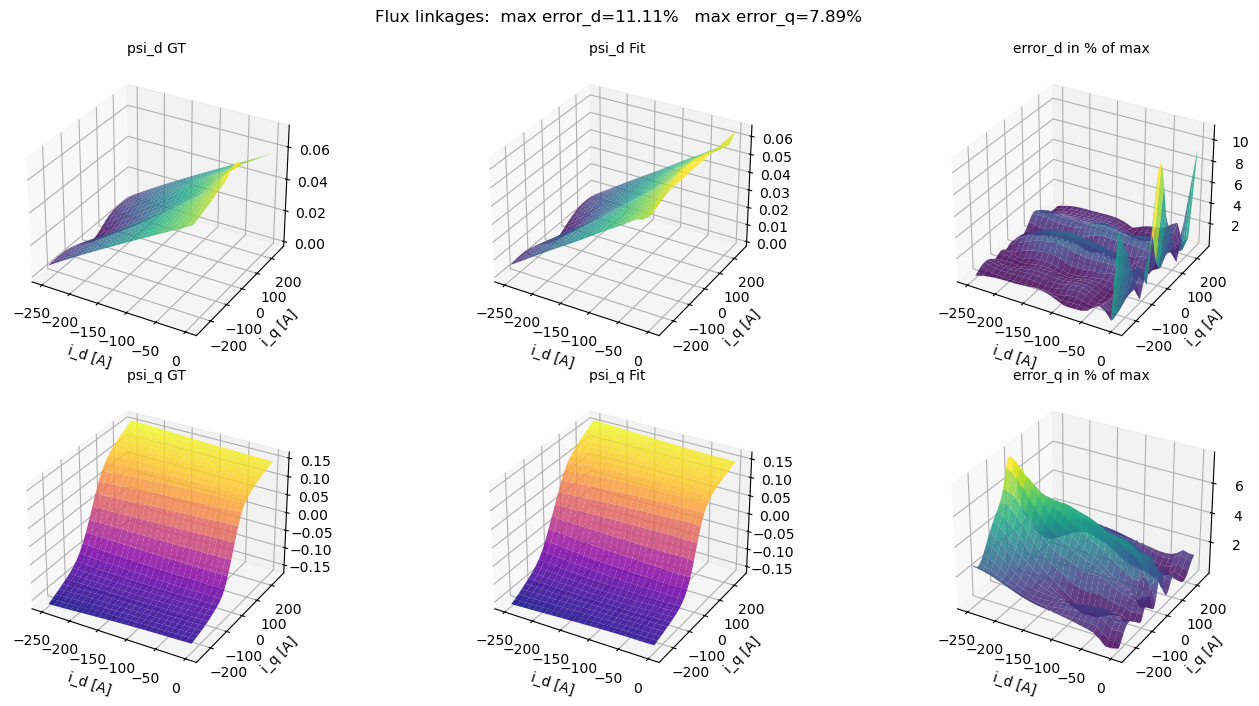

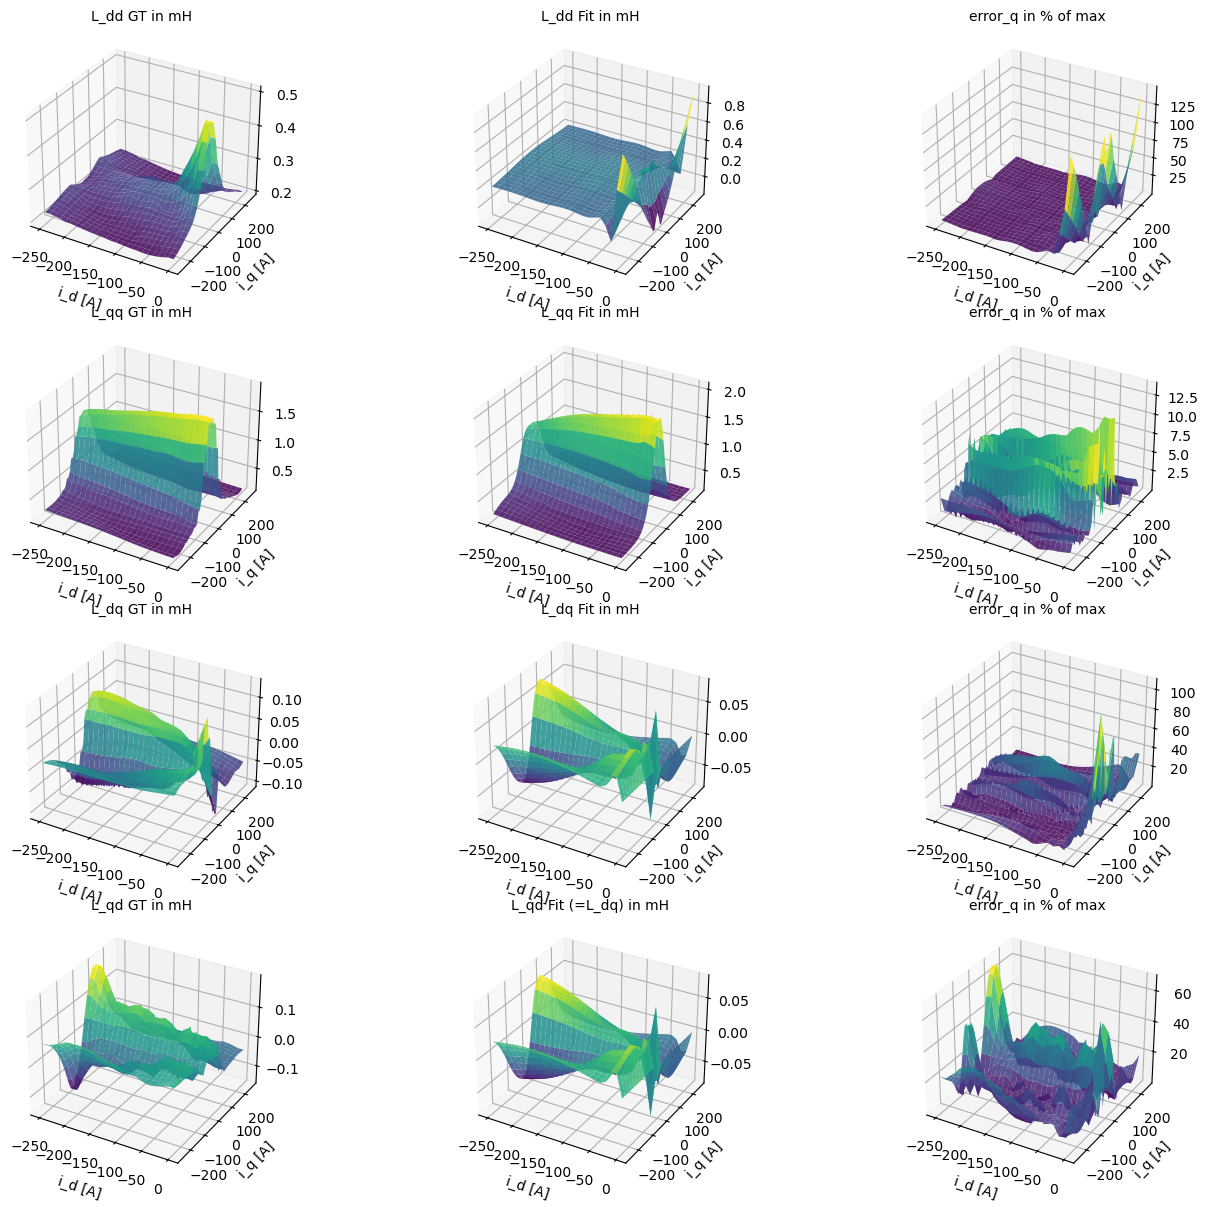

In [98]:
import matplotlib.pyplot as plt
import numpy as np

def plot_fit_comparison(model, id_grid_A, iq_grid_A, luts_phys):


    psi_d_hat, psi_q_hat = jax.vmap(
        jax.vmap(model.flux_physical, (None, 0)), (0, None)
    )(id_grid_A, iq_grid_A)

    Ld_hat, Lq_hat, Ldq_hat = jax.vmap(
        jax.vmap(model.inductances_physical, (None, 0)), (0, None)
    )(id_grid_A, iq_grid_A)

    eps_d = jnp.abs(psi_d_hat - luts_phys["psi_d"]) / jnp.max(jnp.abs(luts_phys["psi_d"])) * 100
    eps_q = jnp.abs(psi_q_hat - luts_phys["psi_q"]) / jnp.max(jnp.abs(luts_phys["psi_q"])) * 100

    ID, IQ = np.meshgrid(np.array(id_grid_A), np.array(iq_grid_A), indexing='ij')

    def surf(ax, data, title, cmap='viridis'):
        ax.plot_surface(ID, IQ, np.array(data), cmap=cmap, alpha=0.85)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('i_d [A]')
        ax.set_ylabel('i_q [A]')

    fig1 = plt.figure(figsize=(15, 7))
    surf(fig1.add_subplot(231, projection='3d'), luts_phys["psi_d"], 'psi_d GT')
    surf(fig1.add_subplot(232, projection='3d'), psi_d_hat,          'psi_d Fit ')
    surf(fig1.add_subplot(233, projection='3d'), eps_d,              'error_d in % of max')
    surf(fig1.add_subplot(234, projection='3d'), luts_phys["psi_q"], 'psi_q GT',  'plasma')
    surf(fig1.add_subplot(235, projection='3d'), psi_q_hat,          'psi_q Fit ', 'plasma')
    surf(fig1.add_subplot(236, projection='3d'), eps_q,              'error_q in % of max')
    fig1.suptitle(
        f'Flux linkages:  max error_d={float(eps_d.max()):.2f}%   max error_q={float(eps_q.max()):.2f}%',
        fontsize=12
    )
    plt.tight_layout()

    eps_Ld  = jnp.abs(Ld_hat  - luts_phys["L_dd"]) / jnp.max(jnp.abs(luts_phys["L_dd"])) * 100
    eps_Lq  = jnp.abs(Lq_hat  - luts_phys["L_qq"]) / jnp.max(jnp.abs(luts_phys["L_qq"])) * 100
    eps_Ldq = jnp.abs(Ldq_hat - luts_phys["L_dq"]) / jnp.max(jnp.abs(luts_phys["L_dq"])) * 100
    eps_Lqd = jnp.abs(Ldq_hat - luts_phys["L_qd"]) / jnp.max(jnp.abs(luts_phys["L_qd"])) * 100

    fig2 = plt.figure(figsize=(15, 12))
    surf(fig2.add_subplot(431, projection='3d'), luts_phys["L_dd"]*1000, 'L_dd GT in mH')
    surf(fig2.add_subplot(432, projection='3d'), Ld_hat*1000,            'L_dd Fit in mH')
    surf(fig2.add_subplot(433, projection='3d'), eps_Ld,            'error_q in % of max')

    surf(fig2.add_subplot(434, projection='3d'), luts_phys["L_qq"]*1000, 'L_qq GT in mH')
    surf(fig2.add_subplot(435, projection='3d'), Lq_hat*1000,            'L_qq Fit in mH')
    surf(fig2.add_subplot(436, projection='3d'), eps_Lq,            'error_q in % of max')

    surf(fig2.add_subplot(437, projection='3d'), luts_phys["L_dq"]*1000, 'L_dq GT in mH')
    surf(fig2.add_subplot(438, projection='3d'), Ldq_hat*1000,           'L_dq Fit in mH')
    surf(fig2.add_subplot(439, projection='3d'), eps_Ldq,           'error_q in % of max')

    surf(fig2.add_subplot(4,3,10, projection='3d'), luts_phys["L_qd"]*1000, 'L_qd GT in mH')
    surf(fig2.add_subplot(4,3,11, projection='3d'), Ldq_hat*1000,           'L_qd Fit (=L_dq) in mH')
    surf(fig2.add_subplot(4,3,12, projection='3d'), eps_Lqd,           'error_q in % of max')

    # fig2.suptitle(
    #     f'Inductances:  max error_Ld={float(eps_Ld.max()):.2f}%'
    #     f'   max error_Lq={float(eps_Lq.max()):.2f}%'
    #     f'   max error_Ldq={float(eps_Ldq.max()):.2f}%'
    #     f'   max error_Lqd={float(eps_Lqd.max()):.2f}%',
    #     fontsize=12
    # )
    plt.tight_layout()
    plt.show()



plot_fit_comparison(model_big, id_grid_A, iq_grid_A, luts_phys)

### PMSM with FluxLinkageSaturator2

In [76]:
from exciting_environments.pmsm import PMSM

In [81]:
class SatPMSM(PMSM):
    lut: eqx.Module
    norm: dict
    def __init__(self, lut, norm, **kwargs):
        super().__init__(**kwargs)
        self.lut = lut
        self.norm = norm

    def _psi_dq(self, i_d, i_q):
        psi_d, psi_q = self.lut.flux_physical(i_d, i_q)
        return psi_d, psi_q
    
    def _inductances(self, i_d, i_q):
        Ld, Lq, Ldq = self.lut.inductances_physical(i_d, i_q)
        return Ld, Lq, Ldq
    
    def currents_to_torque_saturated(self, i_d, i_q):
        Psi_d, Psi_q = self._psi_dq(i_d, i_q)
        return 3 / 2 * self.env_properties.static_params.p * (Psi_d * i_q - Psi_q * i_d)
    
    def nonlinear_ode(self, t, y, args, action):
        i_d, i_q, eps = y
        static_params, omega_el = args
        u_dq = action(t)
        J_k = jnp.array([[0, -1], [1, 0]])
        i_dq = jnp.array([i_d, i_q])
        # p_d = {q: lut_interpolate(*self.LUT_grids[q], self.LUT_values[q], i_d, i_q) for q in self.LUT_grids}
        psi_d, psi_q = self._psi_dq(i_d, i_q)
        L_dd, L_qq, L_dq = self._inductances(i_d, i_q)
        p_d = {"Psi_d": psi_d, "Psi_q": psi_q, "L_dd": L_dd, "L_qq": L_qq, "L_dq": L_dq, "L_qd": L_dq}
        L_diff = jnp.column_stack([p_d[q] for q in ["L_dd", "L_dq", "L_qd", "L_qq"]]).reshape(2, 2)
        L_diff_inv = jnp.linalg.inv(L_diff)
        psi_dq = jnp.column_stack([p_d[psi] for psi in ["Psi_d", "Psi_q"]]).reshape(-1)
        di_dq_1 = jnp.einsum(
            "ij,j->i",
            (-L_diff_inv * static_params.r_s),
            i_dq,
        )
        di_dq_2 = jnp.einsum("ik,k->i", L_diff_inv, u_dq)
        di_dq_3 = jnp.einsum("ij,jk,k->i", -L_diff_inv, J_k, psi_dq) * omega_el
        i_dq_diff = di_dq_1 + di_dq_2 + di_dq_3
        eps_diff = omega_el
        d_y = i_dq_diff[0], i_dq_diff[1], eps_diff
        return d_y

In [82]:
sat_pmsm = SatPMSM(model,norm,saturated=True,motor_variant=MotorVariant.BRUSA)
pmsm = EnvironmentRegistry.PMSM.make(
    saturated=True,
    motor_variant=MotorVariant.BRUSA
    )

In [85]:
obs, motor_env_state = pmsm.reset() #PRNGKey
next_state=motor_env_state
i_dqs=[]
for _ in range(1000):
    act=jnp.array([0.03,0.03])
    obs_next,next_state=pmsm.step(next_state,act)
    i_dqs.append(obs_next[0:2])

In [87]:
obs, motor_env_state = sat_pmsm.reset() #PRNGKey
next_state=motor_env_state
i_dqs_sat=[]
for _ in range(1000):
    act=jnp.array([0.03,0.03])
    obs_next,next_state=sat_pmsm.step(next_state,act)
    i_dqs_sat.append(obs_next[0:2])

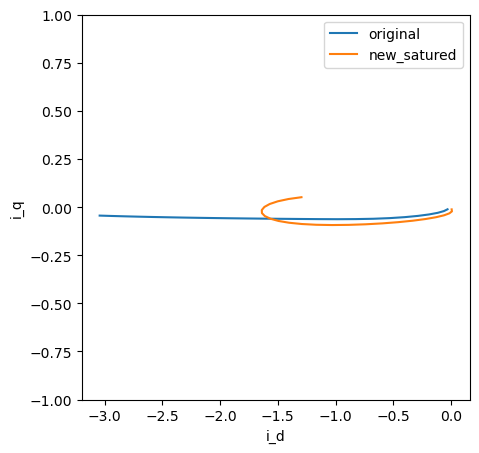

In [94]:
fig,ax=plt.subplots(1,1,figsize=(5,5))
length=25
ax.plot(jnp.array(i_dqs)[:length,0],jnp.array(i_dqs)[:length,1],label="original")
ax.plot(jnp.array(i_dqs_sat)[:length,0],jnp.array(i_dqs_sat)[:length,1],label="new_satured")
# ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_xlabel("i_d")
ax.set_ylabel("i_q")
ax.legend()

## Time

In [ ]:
import time
from functools import partial


In [97]:

def rollout_const(env, init_state, act, n_steps):
    def scan_fn(state, _):
        obs, next_state = env.step(state, act)
        loss = jnp.sum(obs[0:2] ** 2)
        return next_state, loss
    _, losses = jax.lax.scan(scan_fn, init_state, None, length=n_steps)
    return jnp.sum(losses)

def rollout_seq(env, init_state, acts, n_steps):
    def scan_fn(state, act):
        obs, next_state = env.step(state, act)
        loss = jnp.sum(obs[0:2] ** 2)
        return next_state, loss
    _, losses = jax.lax.scan(scan_fn, init_state, acts)
    return jnp.sum(losses)


@partial(jax.jit, static_argnums=(2,))
def fwd_const_pmsm(state, act, n_steps):
    return rollout_const(pmsm, state, act, n_steps)

@partial(jax.jit, static_argnums=(2,))
def fwd_const_sat(state, act, n_steps):
    return rollout_const(sat_pmsm, state, act, n_steps)

@partial(jax.jit, static_argnums=(2,))
def fwd_seq_pmsm(state, acts, n_steps):
    return rollout_seq(pmsm, state, acts, n_steps)

@partial(jax.jit, static_argnums=(2,))
def fwd_seq_sat(state, acts, n_steps):
    return rollout_seq(sat_pmsm, state, acts, n_steps)

@partial(jax.jit, static_argnums=(2,))
def bwd_const_pmsm(state, act, n_steps):
    return jax.grad(lambda a: rollout_const(pmsm, state, a, n_steps))(act)

@partial(jax.jit, static_argnums=(2,))
def bwd_const_sat(state, act, n_steps):
    return jax.grad(lambda a: rollout_const(sat_pmsm, state, a, n_steps))(act)

@partial(jax.jit, static_argnums=(2,))
def bwd_seq_pmsm(state, acts, n_steps):
    return jax.grad(lambda a: rollout_seq(pmsm, state, a, n_steps))(acts)

@partial(jax.jit, static_argnums=(2,))
def bwd_seq_sat(state, acts, n_steps):
    return jax.grad(lambda a: rollout_seq(sat_pmsm, state, a, n_steps))(acts)



key = jax.random.PRNGKey(0)
act_const = jnp.array([0.03, 0.03])
_, state     = pmsm.reset()
_, state_sat = sat_pmsm.reset()



print("Warm-up...")
for n_steps in [1, 10, 50, 100, 500]:
    acts_seq = jax.random.uniform(key, shape=(n_steps, 2), minval=-0.1, maxval=0.1)

    jax.block_until_ready(fwd_const_pmsm(state,     act_const, n_steps))
    jax.block_until_ready(fwd_const_sat( state_sat, act_const, n_steps))
    jax.block_until_ready(bwd_const_pmsm(state,     act_const, n_steps))
    jax.block_until_ready(bwd_const_sat( state_sat, act_const, n_steps))
    jax.block_until_ready(fwd_seq_pmsm(  state,     acts_seq,  n_steps))
    jax.block_until_ready(fwd_seq_sat(   state_sat, acts_seq,  n_steps))
    jax.block_until_ready(bwd_seq_pmsm(  state,     acts_seq,  n_steps))
    jax.block_until_ready(bwd_seq_sat(   state_sat, acts_seq,  n_steps))
print("Warm-up done.\n")



N = 50

def measure(fn, *args):
    t0 = time.perf_counter()
    for _ in range(N):
        out = fn(*args)
    jax.block_until_ready(jax.tree_util.tree_leaves(out))
    return (time.perf_counter() - t0) / N * 1000

sep    = "=" * 60
header = f"  {'n_steps':>8}    {'PMSM':>10}      {'SatPMSM':>10} " #{'Overhead':>8}

for label, fwd_p, fwd_s, bwd_p, bwd_s, use_seq in [
    # ("const action", fwd_const_pmsm, fwd_const_sat, bwd_const_pmsm, bwd_const_sat, False),
    ("seq actions",  fwd_seq_pmsm,   fwd_seq_sat,   bwd_seq_pmsm,   bwd_seq_sat,   True),
]:
    #print(sep)
    print(f"  {label}")
    print(sep)
    print(header)
    print("-" * 60)

    print("  ── Forward ──")
    for n_steps in [1, 10, 50, 100, 500]:
        acts = jax.random.uniform(key, shape=(n_steps, 2), minval=-0.1, maxval=0.1) if use_seq else act_const
        t_p = measure(fwd_p, state,     acts, n_steps)
        t_s = measure(fwd_s, state_sat, acts, n_steps)
        print(f"  n={n_steps:4d}       {t_p:8.3f} ms  {t_s:8.3f} ms") #{t_s/t_p:6.2f}x

    print("  ── Backward dloss/dacts ──")
    for n_steps in [1, 10, 50, 100, 500]:
        acts = jax.random.uniform(key, shape=(n_steps, 2), minval=-0.1, maxval=0.1) if use_seq else act_const
        t_p = measure(bwd_p, state,     acts, n_steps)
        t_s = measure(bwd_s, state_sat, acts, n_steps)
        print(f"  n={n_steps:4d}       {t_p:8.3f} ms  {t_s:8.3f} ms  ") #{t_s/t_p:6.2f}x

print(sep)

Warm-up...
Warm-up done.

  seq actions
   n_steps          PMSM         SatPMSM 
------------------------------------------------------------
  ── Forward ──
  n=   1          0.820 ms     0.217 ms
  n=  10          1.495 ms     0.858 ms
  n=  50          6.406 ms     3.415 ms
  n= 100         12.735 ms     6.455 ms
  n= 500         63.793 ms    31.040 ms
  ── Backward dloss/dacts ──
  n=   1          0.117 ms     0.114 ms  
  n=  10          3.698 ms     3.083 ms  
  n=  50         17.813 ms    14.461 ms  
  n= 100         35.253 ms    28.772 ms  
  n= 500        176.499 ms   142.003 ms  
